# A2A Negotiation — Full Model Matrix (One Click)

Run **Runtime → Run all** (`Ctrl+F9`).

This notebook runs every buyer × seller model combination you define, accumulates results,
then produces a full cross-model comparison analysis.

---
## ⚙️ Configuration — only edit this cell

In [ ]:
# ── API Keys ──────────────────────────────────────────────────────────────────
OPENAI_API_KEY    = ""
ANTHROPIC_API_KEY = ""
DEEPSEEK_API_KEY  = ""
GOOGLE_API_KEY    = ""

# ── Model Matrix ──────────────────────────────────────────────────────────────
# All buyer × seller combinations will be run.
# Remove any models you don't have API keys for.
BUYER_MODELS  = [
    "gpt-3.5-turbo",
    "claude-haiku-4-5-20251001",
    "gemini-2.5-flash",
]
SELLER_MODELS = [
    "gpt-3.5-turbo",
    "claude-haiku-4-5-20251001",
    "gemini-2.5-flash",
]

# ── Summary/Judge Model ────────────────────────────────────────────────────────
# Kept fixed across all runs for fair comparison.
SUMMARY_MODEL    = "gpt-3.5-turbo"

# ── Experiment Settings ────────────────────────────────────────────────────────
MAX_TURNS        = 30
NUM_EXPERIMENTS  = 3                  # trials per product × budget scenario × model pair
BUDGET_SCENARIOS = None               # None = all 5; or e.g. ["retail", "mid", "low"]

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_DIR    = "/content/A2A-Negotiations"
RESULTS_DIR = f"{REPO_DIR}/results"

# ── Derived ───────────────────────────────────────────────────────────────────
MODEL_PAIRS = [(b, s) for b in BUYER_MODELS for s in SELLER_MODELS]
print(f"Model matrix: {len(BUYER_MODELS)} buyers x {len(SELLER_MODELS)} sellers = {len(MODEL_PAIRS)} pairs")
print()
for b, s in MODEL_PAIRS:
    print(f"  buyer={b:<35}  seller={s}")

Model matrix: 3 buyers x 3 sellers = 9 pairs

  buyer=gpt-3.5-turbo                        seller=gpt-3.5-turbo
  buyer=gpt-3.5-turbo                        seller=claude-haiku-4-5-20251001
  buyer=gpt-3.5-turbo                        seller=gemini-2.5-flash
  buyer=claude-haiku-4-5-20251001            seller=gpt-3.5-turbo
  buyer=claude-haiku-4-5-20251001            seller=claude-haiku-4-5-20251001
  buyer=claude-haiku-4-5-20251001            seller=gemini-2.5-flash
  buyer=gemini-2.5-flash                     seller=gpt-3.5-turbo
  buyer=gemini-2.5-flash                     seller=claude-haiku-4-5-20251001
  buyer=gemini-2.5-flash                     seller=gemini-2.5-flash


---
## 1 · Setup — clone, install, patch

In [ ]:
import os, subprocess, sys

if not os.path.isdir(REPO_DIR):
    print("Cloning repo...")
    subprocess.run(
        ["git", "clone", "https://github.com/catchshashank/A2A-Negotiations.git", REPO_DIR],
        check=True
    )
    print("Cloned.")
else:
    print("Repo already present, skipping clone.")

Repo already present, skipping clone.


In [ ]:
print("Installing dependencies...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements.txt"],
    check=True
)
print("Dependencies installed.")

Installing dependencies...
Dependencies installed.


In [ ]:
import os

# ── Write Config.py ───────────────────────────────────────────────────────────
with open(f"{REPO_DIR}/Config.py", "w") as f:
    f.write(f'OPENAI_API_KEY    = "{OPENAI_API_KEY}"\n')
    f.write(f'ANTHROPIC_API_KEY = "{ANTHROPIC_API_KEY}"\n')
    f.write(f'DEEPSEEK_API_KEY  = "{DEEPSEEK_API_KEY}"\n')
    f.write(f'GOOGLE_API_KEY    = "{GOOGLE_API_KEY}"\n')
    f.write( 'ZHI_API_KEY       = ""\n')
print("Config.py written.")

# ── Patch main.py ─────────────────────────────────────────────────────────────
main_path = f"{REPO_DIR}/main.py"
with open(main_path) as f:
    src = f.read()
src = src.replace(
    "from Conversation import Conversation",
    "from core.Conversation import Conversation",
)
with open(main_path, "w") as f:
    f.write(src)
print("main.py patched.")

# ── Patch core/Conversation.py ────────────────────────────────────────────────
conv_path = f"{REPO_DIR}/core/Conversation.py"
with open(conv_path) as f:
    src = f.read()
src = src.replace(
    "from LanguageModel import LanguageModel",
    "from core.LanguageModel import LanguageModel",
)
if "import logging" not in src:
    src = src.replace(
        "import re\n",
        "import re\nimport logging\nlogger = logging.getLogger(__name__)\n",
    )

# FIX: max_turns off-by-one + broken max_turns_reached classification.
# BUG 1 — turn_count is incremented at the bottom of the loop, so after the
#          loop exits naturally turn_count == max_turns + 1, causing completed_turns
#          to be saved one over the limit.
# BUG 2 — the post-loop check is `turn_count > self.max_turns`, but the while
#          condition is `turn_count <= self.max_turns`, so turn_count is always
#          exactly max_turns+1 when the loop exits — meaning the check fires
#          correctly BUT completed_turns is still off by one.
# FIX: record completed_turns before incrementing, and tighten the exit logic.
OLD_LOOP_END = (
    "            turn_count += 1\n"
    "\n"
    "        self.completed_turns = turn_count\n"
    "\n"
    "        if turn_count > self.max_turns and not self.negotiation_completed:\n"
    "            self.negotiation_completed = True\n"
    "            self.negotiation_result = \"max_turns_reached\"\n"
    "            print(\"\\nReached maximum turns without a natural conclusion.\")\n"
)
NEW_LOOP_END = (
    "            self.completed_turns = turn_count  # record before incrementing\n"
    "            turn_count += 1\n"
    "\n"
        # After loop: turn_count == max_turns+1 if exhausted, or broke early
    "        if not self.negotiation_completed:\n"
    "            self.completed_turns = self.max_turns  # cap at limit\n"
    "            self.negotiation_completed = True\n"
    "            self.negotiation_result = \"max_turns_reached\"\n"
    "            print(\"\\nReached maximum turns without a natural conclusion.\")\n"
)
if OLD_LOOP_END in src:
    src = src.replace(OLD_LOOP_END, NEW_LOOP_END)
    print("  Conversation.py: max_turns off-by-one + result classification fixed.")
elif "cap at limit" in src:
    print("  Conversation.py: max_turns fix already applied.")
else:
    print("  WARNING: Conversation.py loop end not matched — check manually.")

with open(conv_path, "w") as f:
    f.write(src)
print("core/Conversation.py patched.")

# ── Patch core/LanguageModel.py ───────────────────────────────────────────────
lm_path = f"{REPO_DIR}/core/LanguageModel.py"
with open(lm_path) as f:
    src = f.read()

# Remove double @staticmethod from any previous patch run
src = src.replace("    @staticmethod\n    @staticmethod\n", "    @staticmethod\n")

# FIX A: Anthropic — _ensure_alternating content-list bug
# content += str concatenation fails when content is a list -> HTTP 400
OLD_ALT = (
    "    @staticmethod\n"
    "    def _ensure_alternating(messages: List[Dict]) -> List[Dict]:\n"
    "        \"\"\"\n"
    "        Anthropic requires strictly alternating user/assistant turns.\n"
    "        Merge consecutive same-role messages by concatenating content.\n"
    "        \"\"\"\n"
    "        if not messages:\n"
    "            return messages\n"
    "        out = [messages[0].copy()]\n"
    "        for m in messages[1:]:\n"
    "            if m[\"role\"] == out[-1][\"role\"]:\n"
    "                out[-1][\"content\"] += \"\\n\" + m[\"content\"]\n"
    "            else:\n"
    "                out.append(m.copy())\n"
    "        return out"
)
NEW_ALT = (
    "    @staticmethod\n"
    "    def _ensure_alternating(messages: List[Dict]) -> List[Dict]:\n"
    "        \"\"\"\n"
    "        Anthropic requires strictly alternating user/assistant turns.\n"
    "        Merge consecutive same-role messages; content always normalised to str.\n"
    "        \"\"\"\n"
    "        def _to_str(c):\n"
    "            if isinstance(c, list):\n"
    "                return ' '.join(b.get('text', '') if isinstance(b, dict) else str(b) for b in c)\n"
    "            return c or ''\n"
    "        if not messages:\n"
    "            return messages\n"
    "        out = [{'role': messages[0]['role'], 'content': _to_str(messages[0]['content'])}]\n"
    "        for m in messages[1:]:\n"
    "            cs = _to_str(m['content'])\n"
    "            if m['role'] == out[-1]['role']:\n"
    "                out[-1]['content'] += '\\n' + cs\n"
    "            else:\n"
    "                out.append({'role': m['role'], 'content': cs})\n"
    "        return out"
)
if OLD_ALT in src:
    src = src.replace(OLD_ALT, NEW_ALT)
    print("  LanguageModel.py: Anthropic _ensure_alternating fixed.")
elif "def _to_str" in src:
    print("  LanguageModel.py: _ensure_alternating already patched.")
else:
    print("  WARNING: _ensure_alternating not matched.")

# FIX B: Anthropic — explicit str normalisation before send
OLD_SEND = "                    response = self.client.messages.create(\n"
GUARD    = "                    # Ensure content is plain str for Anthropic\n"
NEW_SEND = (
    "                    # Ensure content is plain str for Anthropic\n"
    "                    chat_msgs = [\n"
    "                        {'role': m['role'],\n"
    "                         'content': m['content'] if isinstance(m['content'], str)\n"
    "                                    else ' '.join(b.get('text', '') if isinstance(b, dict)\n"
    "                                                  else str(b) for b in m['content'])}\n"
    "                        for m in chat_msgs\n"
    "                    ]\n"
)
if GUARD not in src and OLD_SEND in src:
    src = src.replace(OLD_SEND, NEW_SEND + OLD_SEND)
    print("  LanguageModel.py: Anthropic pre-send normalisation added.")
elif GUARD in src:
    print("  LanguageModel.py: Anthropic pre-send normalisation already present.")

# FIX C: Gemini — broken call structure + content-list bug
# The original code passes contents as a flat list of strings, discarding all
# role information. Fixed to use typed Content/Part objects with proper roles,
# and system messages are passed via system_instruction instead of being
# prepended as user turns.
OLD_GEMINI = (
    "                elif self.provider == \"google\":\n"
    "                    validated = []\n"
    "                    for m in messages:\n"
    "                        if m[\"role\"] == \"system\":\n"
    "                            validated.append({\"role\": \"user\", \"content\": f\"System: {m['content']}\"})"
    "\n"
    "                        else:\n"
    "                            validated.append(m)\n"
    "                    response = self.client.models.generate_content(\n"
    "                        model=self.model_name,\n"
    "                        contents=[m[\"content\"] for m in validated],\n"
    "                        generation_config={\n"
    "                            \"temperature\": temperature,\n"
    "                            \"max_output_tokens\": max_tokens,\n"
    "                        },\n"
    "                    )\n"
    "                    return response.text\n"
)
NEW_GEMINI = (
    "                elif self.provider == \"google\":\n"
    "                    from google.genai import types as gtypes\n"
    "                    def _gs(c):\n"
    "                        if isinstance(c, list):\n"
    "                            return ' '.join(b.get('text','') if isinstance(b,dict) else str(b) for b in c)\n"
    "                        return c or ''\n"
    "                    role_map = {'user':'user','assistant':'model','system':'user','model':'model'}\n"
    "                    system_parts, contents = [], []\n"
    "                    for m in messages:\n"
    "                        if m['role'] == 'system':\n"
    "                            system_parts.append(_gs(m['content']))\n"
    "                        else:\n"
    "                            contents.append(gtypes.Content(\n"
    "                                role=role_map.get(m['role'], 'user'),\n"
    "                                parts=[gtypes.Part(text=_gs(m['content']))]))\n"
    "                    config = gtypes.GenerateContentConfig(\n"
    "                        temperature=temperature,\n"
    "                        max_output_tokens=max_tokens,\n"
    "                        system_instruction=' '.join(system_parts) if system_parts else None,\n"
    "                    )\n"
    "                    response = self.client.models.generate_content(\n"
    "                        model=self.model_name,\n"
    "                        contents=contents,\n"
    "                        config=config,\n"
    "                    )\n"
    "                    return response.text\n"
)
if OLD_GEMINI in src:
    src = src.replace(OLD_GEMINI, NEW_GEMINI)
    print("  LanguageModel.py: Gemini call structure + content-list fixed.")
elif "gtypes.Content" in src:
    print("  LanguageModel.py: Gemini already patched.")
else:
    print("  WARNING: Gemini block not matched — check manually.")

with open(lm_path, "w") as f:
    f.write(src)
print("core/LanguageModel.py patched.")

os.makedirs(RESULTS_DIR, exist_ok=True)
print("\nAll patches applied. Ready to run.")


Config.py written.
main.py patched.
  Conversation.py: max_turns fix already applied.
core/Conversation.py patched.
  LanguageModel.py: _ensure_alternating already patched.
  LanguageModel.py: Anthropic pre-send normalisation already present.
  LanguageModel.py: Gemini already patched.
core/LanguageModel.py patched.

All patches applied. Ready to run.


---
## 2 · Run model matrix

Each pair runs sequentially. Already-completed scenarios are skipped automatically
(safe to re-run if interrupted).

In [19]:
import time

total_pairs   = len(MODEL_PAIRS)
failed_pairs  = []
skipped_pairs = []

for pair_idx, (buyer, seller) in enumerate(MODEL_PAIRS, 1):
    print(f"\n{'='*70}")
    print(f"[{pair_idx}/{total_pairs}] buyer={buyer}  seller={seller}")
    print(f"{'='*70}")

    cmd = [
        sys.executable, f"{REPO_DIR}/main.py",
        "--products-file",   f"{REPO_DIR}/dataset/products.json",
        "--buyer-model",     buyer,
        "--seller-model",    seller,
        "--summary-model",   SUMMARY_MODEL,
        "--max-turns",       str(MAX_TURNS),
        "--num-experiments", str(NUM_EXPERIMENTS),
        "--output-dir",      RESULTS_DIR,
    ]
    if BUDGET_SCENARIOS:
        cmd += ["--budget-scenarios"] + BUDGET_SCENARIOS

    t0   = time.time()
    proc = subprocess.Popen(
        cmd, cwd=REPO_DIR,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    )
    all_skipped = True
    for line in proc.stdout:
        print(line, end="", flush=True)
        if "Running" in line and "experiment" in line:
            all_skipped = False
    proc.wait()
    elapsed = time.time() - t0

    if proc.returncode != 0:
        print(f"\n  ERROR (exit {proc.returncode}) — pair will be retried if you re-run.")
        failed_pairs.append((buyer, seller))
    elif all_skipped:
        print(f"  (all scenarios already complete — skipped in {elapsed:.0f}s)")
        skipped_pairs.append((buyer, seller))
    else:
        print(f"  Done in {elapsed:.0f}s")

print(f"\n{'='*70}")
print(f"Matrix complete: {total_pairs} pairs, {len(failed_pairs)} failed, {len(skipped_pairs)} already done.")
if failed_pairs:
    print("Failed pairs:")
    for b, s in failed_pairs:
        print(f"  buyer={b}  seller={s}")

Streaming output truncated to the last 5000 lines.

[Turn 1] Seller: Hey! Great choice – those are fantastic headphones. I'm definitely open to working with you. What price range were you thinking? Keep in mind they're currently at $399 retail, but I can see what I can do depending on what you're looking for.
[Turn 1] Price on record: $399.00

[Turn 1] Buyer: Thanks! I'm definitely interested in the headphones. I was hoping to get them for around $339. Would that be possible?

[Turn 2] Seller: I appreciate the offer! $339 is a solid price, but I'd need to stay a bit higher than that to make it work on my end. How about we meet somewhere in the middle – I could do $369? That's still a nice savings from the retail price, and you're getting an incredible product with industry-leading noise cancellation and 30-hour battery life. Does that work better for you?
[Turn 2] Price on record: $339.00

[Turn 2] Buyer: I appreciate you coming down. $369 is getting closer, but I was hoping for someth

---
## 3 · Load all results

In [20]:
import json, glob
import pandas as pd
import numpy as np

records = []
for path in glob.glob(os.path.join(RESULTS_DIR, "**/*.json"), recursive=True):
    with open(path) as f:
        data = json.load(f)
    retail      = float(data["product_data"]["Retail Price"].replace("$","").replace(",",""))
    wholesale   = float(data["product_data"]["Wholesale Price"].replace("$","").replace(",",""))
    final_price = data["seller_price_offers"][-1] if data["seller_price_offers"] else retail
    result      = data.get("negotiation_result", "unknown")
    accepted    = result == "accepted"
    records.append({
        "file":            path,
        "product_id":      data["product_id"],
        "product_name":    data["product_data"]["Product Name"],
        "buyer_model":     data["models"]["buyer"],
        "seller_model":    data["models"]["seller"],
        "budget_scenario": data.get("budget_scenario"),
        "budget":          data.get("budget"),
        "retail_price":    retail,
        "wholesale_price": wholesale,
        "final_price":     final_price,
        "result":          result,
        "accepted":        accepted,
        "completed_turns": data.get("completed_turns", 0),
        "prr_buyer":       (retail - final_price) / retail * 100 if accepted else None,
        "seller_profit":   final_price - wholesale                if accepted else None,
        "overpayment":     accepted and final_price > retail,
        "deadlock":        result == "max_turns_reached",
        "constraint_vio":  accepted and final_price < wholesale,
    })

df = pd.DataFrame(records)

# Short labels for display
label_map = {
    "gpt-3.5-turbo":            "GPT-3.5",
    "gpt-4o":                   "GPT-4o",
    "gpt-4o-mini":              "GPT-4o-mini",
    "claude-3-5-haiku-20241022":"Claude-Haiku",
    "claude-3-5-sonnet-20241022":"Claude-Sonnet",
    "claude-3-opus-20240229":   "Claude-Opus",
    "gemini-2.0-flash":         "Gemini-Flash",
    "gemini-1.5-pro":           "Gemini-Pro",
    "deepseek-chat":            "DeepSeek",
}
df["buyer_label"]  = df["buyer_model"].map(lambda x: label_map.get(x, x))
df["seller_label"] = df["seller_model"].map(lambda x: label_map.get(x, x))

print(f"Loaded {len(df)} records across {df['buyer_model'].nunique()} buyer models "
      f"and {df['seller_model'].nunique()} seller models.")
print()
print("Pairs found:")
for (b, s), grp in df.groupby(["buyer_label", "seller_label"]):
    print(f"  {b:<18} vs {s:<18}  n={len(grp)}")

Loaded 405 records across 3 buyer models and 3 seller models.

Pairs found:
  GPT-3.5            vs GPT-3.5             n=45
  GPT-3.5            vs claude-haiku-4-5-20251001  n=45
  GPT-3.5            vs gemini-2.5-flash    n=45
  claude-haiku-4-5-20251001 vs GPT-3.5             n=45
  claude-haiku-4-5-20251001 vs claude-haiku-4-5-20251001  n=45
  claude-haiku-4-5-20251001 vs gemini-2.5-flash    n=45
  gemini-2.5-flash   vs GPT-3.5             n=45
  gemini-2.5-flash   vs claude-haiku-4-5-20251001  n=45
  gemini-2.5-flash   vs gemini-2.5-flash    n=45


---
## 4 · Summary tables

In [21]:
agg = df.groupby(["buyer_label", "seller_label"]).agg(
    n             = ("accepted",        "count"),
    deal_rate     = ("accepted",        "mean"),
    avg_prr       = ("prr_buyer",       "mean"),
    avg_profit    = ("seller_profit",   "mean"),
    avg_turns     = ("completed_turns", "mean"),
    overpayment   = ("overpayment",     "mean"),
    deadlock      = ("deadlock",        "mean"),
    constraint    = ("constraint_vio",  "mean"),
).reset_index()

fmt_pct  = lambda x: f"{x:.1%}" if pd.notna(x) else "n/a"
fmt_val  = lambda x: f"{x:.2f}" if pd.notna(x) else "n/a"
fmt_usd  = lambda x: f"${x:.0f}" if pd.notna(x) else "n/a"

display_agg = agg.copy()
display_agg["deal_rate"]   = display_agg["deal_rate"].map(fmt_pct)
display_agg["avg_prr"]     = display_agg["avg_prr"].map(fmt_val)
display_agg["avg_profit"]  = display_agg["avg_profit"].map(fmt_usd)
display_agg["avg_turns"]   = display_agg["avg_turns"].map(fmt_val)
display_agg["overpayment"] = display_agg["overpayment"].map(fmt_pct)
display_agg["deadlock"]    = display_agg["deadlock"].map(fmt_pct)
display_agg["constraint"]  = display_agg["constraint"].map(fmt_pct)

display_agg.columns = ["Buyer", "Seller", "N", "Deal Rate",
                        "Avg PRR %", "Avg Seller Profit", "Avg Turns",
                        "Overpayment", "Deadlock", "Constraint Vio"]
print("=== Full Model-Pair Summary ===")
display(display_agg)

=== Full Model-Pair Summary ===


,Buyer,Seller,N,Deal Rate,Avg PRR %,Avg Seller Profit,Avg Turns,Overpayment,Deadlock,Constraint Vio
0,GPT-3.5,GPT-3.5,45,57.8%,16.70,$297,5.71,2.2%,13.3%,0.0%
1,GPT-3.5,claude-haiku-4-5-20251001,45,48.9%,10.18,$369,7.11,0.0%,17.8%,0.0%
2,GPT-3.5,gemini-2.5-flash,45,44.4%,9.32,$417,3.20,0.0%,4.4%,0.0%
3,claude-haiku-4-5-20251001,GPT-3.5,45,80.0%,24.27,$199,2.76,0.0%,2.2%,4.4%
4,claude-haiku-4-5-20251001,claude-haiku-4-5-20251001,45,53.3%,15.99,$293,3.11,0.0%,0.0%,4.4%
5,claude-haiku-4-5-20251001,gemini-2.5-flash,45,68.9%,17.35,$279,2.20,0.0%,0.0%,0.0%
6,gemini-2.5-flash,GPT-3.5,45,64.4%,25.29,$163,2.20,0.0%,0.0%,0.0%
7,gemini-2.5-flash,claude-haiku-4-5-20251001,45,66.7%,19.76,$232,2.84,0.0%,0.0%,0.0%
8,gemini-2.5-flash,gemini-2.5-flash,45,64.4%,16.58,$284,3.42,0.0%,0.0%,0.0%


In [22]:
# ── Pivot tables: one metric per grid ────────────────────────────────────────
def pivot_metric(metric, label):
    p = agg.pivot(index="buyer_label", columns="seller_label", values=metric)
    print(f"\n--- {label} ---")
    display(p.style.format("{:.1%}" if "rate" in metric or metric in ["overpayment","deadlock","constraint"] else "{:.2f}"
                           ).background_gradient(cmap="RdYlGn", axis=None))

pivot_metric("deal_rate",  "Deal Rate (buyer × seller)")
pivot_metric("avg_prr",    "Avg Price Reduction Rate % (buyer × seller)")
pivot_metric("avg_turns",  "Avg Turns to Conclusion (buyer × seller)")
pivot_metric("deadlock",   "Deadlock Rate (buyer × seller)")


--- Deal Rate (buyer × seller) ---


seller_label,GPT-3.5,claude-haiku-4-5-20251001,gemini-2.5-flash
buyer_label,,,
GPT-3.5,57.8%,48.9%,44.4%
claude-haiku-4-5-20251001,80.0%,53.3%,68.9%
gemini-2.5-flash,64.4%,66.7%,64.4%



--- Avg Price Reduction Rate % (buyer × seller) ---


seller_label,GPT-3.5,claude-haiku-4-5-20251001,gemini-2.5-flash
buyer_label,,,
GPT-3.5,16.70,10.18,9.32
claude-haiku-4-5-20251001,24.27,15.99,17.35
gemini-2.5-flash,25.29,19.76,16.58



--- Avg Turns to Conclusion (buyer × seller) ---


seller_label,GPT-3.5,claude-haiku-4-5-20251001,gemini-2.5-flash
buyer_label,,,
GPT-3.5,5.71,7.11,3.20
claude-haiku-4-5-20251001,2.76,3.11,2.20
gemini-2.5-flash,2.20,2.84,3.42



--- Deadlock Rate (buyer × seller) ---


seller_label,GPT-3.5,claude-haiku-4-5-20251001,gemini-2.5-flash
buyer_label,,,
GPT-3.5,13.3%,17.8%,4.4%
claude-haiku-4-5-20251001,2.2%,0.0%,0.0%
gemini-2.5-flash,0.0%,0.0%,0.0%


In [23]:
per_product = df.groupby(["product_name", "budget_scenario", "buyer_label", "seller_label"]).agg(
    n         = ("accepted",        "count"),
    deal_rate = ("accepted",        "mean"),
    avg_final = ("final_price",     "mean"),
    avg_prr   = ("prr_buyer",       "mean"),
    avg_turns = ("completed_turns", "mean"),
).reset_index()
per_product["deal_rate"] = per_product["deal_rate"].map("{:.0%}".format)
per_product["avg_final"] = per_product["avg_final"].map("${:.0f}".format)
per_product["avg_prr"]   = per_product["avg_prr"].map(lambda x: f"{x:.1f}%" if pd.notna(x) else "n/a")
per_product["avg_turns"] = per_product["avg_turns"].map("{:.1f}".format)
per_product.columns      = ["Product","Budget","Buyer","Seller","N","Deal Rate","Avg Final Price","Avg PRR","Avg Turns"]
print("=== Per-Product x Budget x Model Pair ===")
display(per_product)

=== Per-Product x Budget x Model Pair ===


,Product,Budget,Buyer,Seller,N,Deal Rate,Avg Final Price,Avg PRR,Avg Turns
0,Apple MacBook Pro 16-inch (M3 Pro),high,GPT-3.5,GPT-3.5,3,33%,$2500,-20.0%,0.3
1,Apple MacBook Pro 16-inch (M3 Pro),high,GPT-3.5,claude-haiku-4-5-20251001,3,100%,$2432,2.7%,1.3
2,Apple MacBook Pro 16-inch (M3 Pro),high,GPT-3.5,gemini-2.5-flash,3,67%,$2433,3.0%,1.7
3,Apple MacBook Pro 16-inch (M3 Pro),high,claude-haiku-4-5-20251001,GPT-3.5,3,67%,$2150,16.0%,2.3
4,Apple MacBook Pro 16-inch (M3 Pro),high,claude-haiku-4-5-20251001,claude-haiku-4-5-20251001,3,100%,$2320,7.2%,2.3
...,...,...,...,...,...,...,...,...,...
130,Sony WH-1000XM5 Wireless Headphones,wholesale,claude-haiku-4-5-20251001,claude-haiku-4-5-20251001,3,33%,$220,44.9%,4.7
131,Sony WH-1000XM5 Wireless Headphones,wholesale,claude-haiku-4-5-20251001,gemini-2.5-flash,3,67%,$246,44.9%,2.7
132,Sony WH-1000XM5 Wireless Headphones,wholesale,gemini-2.5-flash,GPT-3.5,3,67%,$220,44.9%,2.0
133,Sony WH-1000XM5 Wireless Headphones,wholesale,gemini-2.5-flash,claude-haiku-4-5-20251001,3,67%,$225,44.9%,3.0


---
## 5 · Charts

Saved to /content/A2A-Negotiations/results/heatmap_deal_rate.png


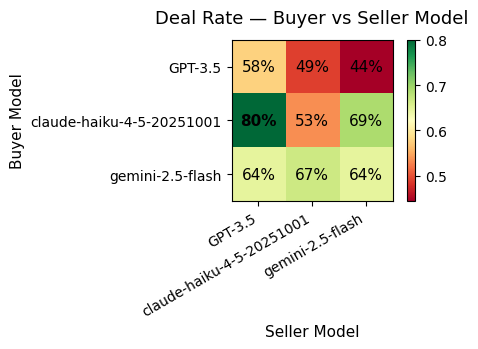

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

def heatmap(pivot_df, title, fmt="{:.0%}", cmap="RdYlGn", save_name=None):
    fig, ax = plt.subplots(figsize=(max(5, len(pivot_df.columns)*1.6),
                                     max(3, len(pivot_df)*1.2)))
    data = pivot_df.values.astype(float)
    im   = ax.imshow(data, cmap=cmap, vmin=np.nanmin(data), vmax=np.nanmax(data))
    ax.set_xticks(range(len(pivot_df.columns)))
    ax.set_xticklabels(pivot_df.columns, rotation=30, ha="right", fontsize=10)
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_yticklabels(pivot_df.index, fontsize=10)
    ax.set_xlabel("Seller Model", fontsize=11)
    ax.set_ylabel("Buyer Model",  fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            val = data[i, j]
            if not np.isnan(val):
                ax.text(j, i, fmt.format(val), ha="center", va="center",
                        fontsize=11, color="black",
                        fontweight="bold" if val == np.nanmax(data) else "normal")
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    if save_name:
        plt.savefig(f"{RESULTS_DIR}/{save_name}", dpi=150, bbox_inches="tight")
        print(f"Saved to {RESULTS_DIR}/{save_name}")
    plt.show()

deal_pivot = agg.pivot(index="buyer_label", columns="seller_label", values="deal_rate")
heatmap(deal_pivot, "Deal Rate — Buyer vs Seller Model",
        fmt="{:.0%}", cmap="RdYlGn", save_name="heatmap_deal_rate.png")

Saved to /content/A2A-Negotiations/results/heatmap_prr.png


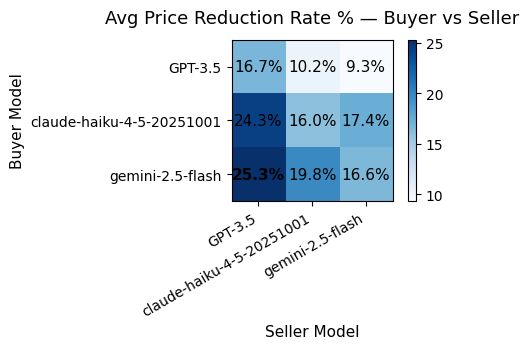

In [25]:
prr_pivot = agg.pivot(index="buyer_label", columns="seller_label", values="avg_prr")
heatmap(prr_pivot, "Avg Price Reduction Rate % — Buyer vs Seller",
        fmt="{:.1f}%", cmap="Blues", save_name="heatmap_prr.png")

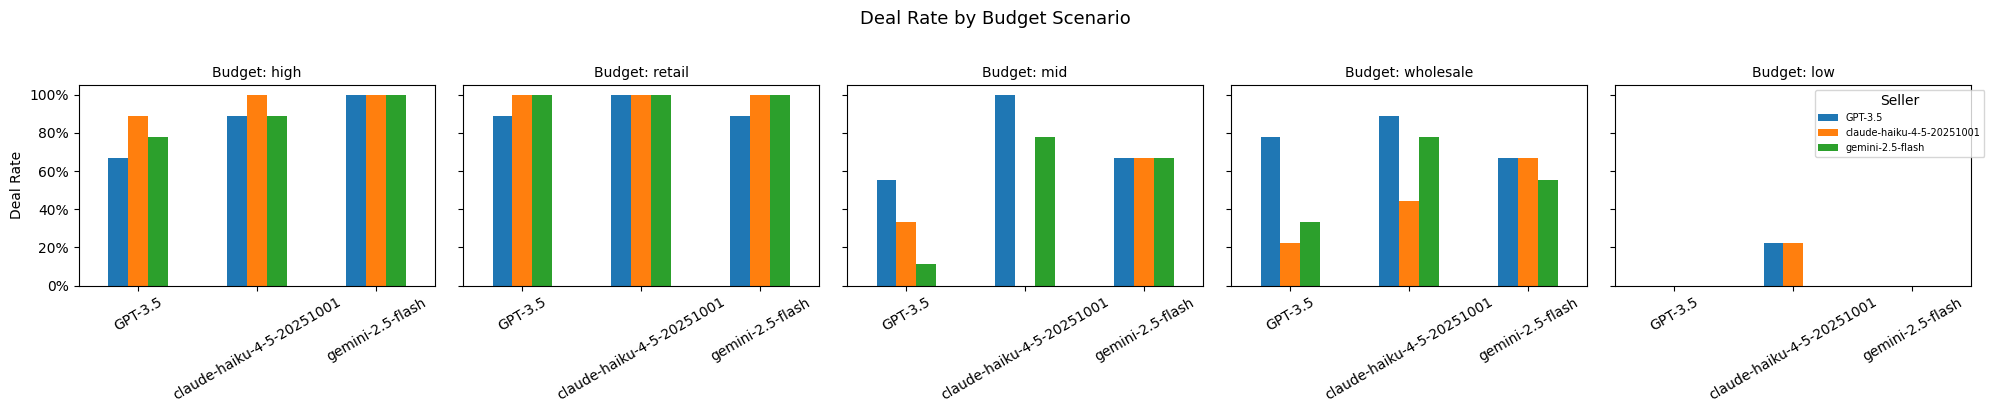

Saved to /content/A2A-Negotiations/results/deal_rate_by_budget_matrix.png


In [26]:
budget_order = ["high", "retail", "mid", "wholesale", "low"]
existing_budgets = [b for b in budget_order if b in df["budget_scenario"].unique()]

fig, axes = plt.subplots(
    1, len(existing_budgets),
    figsize=(4 * len(existing_budgets), 4),
    sharey=True
)
if len(existing_budgets) == 1:
    axes = [axes]

for ax, budget in zip(axes, existing_budgets):
    sub = df[df["budget_scenario"] == budget]
    rates = sub.groupby(["buyer_label", "seller_label"])["accepted"].mean().reset_index()
    pivot = rates.pivot(index="buyer_label", columns="seller_label", values="accepted")
    pivot.plot(kind="bar", ax=ax, rot=30, legend=(ax == axes[-1]))
    ax.set_title(f"Budget: {budget}", fontsize=10)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    if ax == axes[0]:
        ax.set_ylabel("Deal Rate")
    if ax == axes[-1]:
        ax.legend(title="Seller", bbox_to_anchor=(1.05, 1), fontsize=7)

fig.suptitle("Deal Rate by Budget Scenario", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/deal_rate_by_budget_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {RESULTS_DIR}/deal_rate_by_budget_matrix.png")

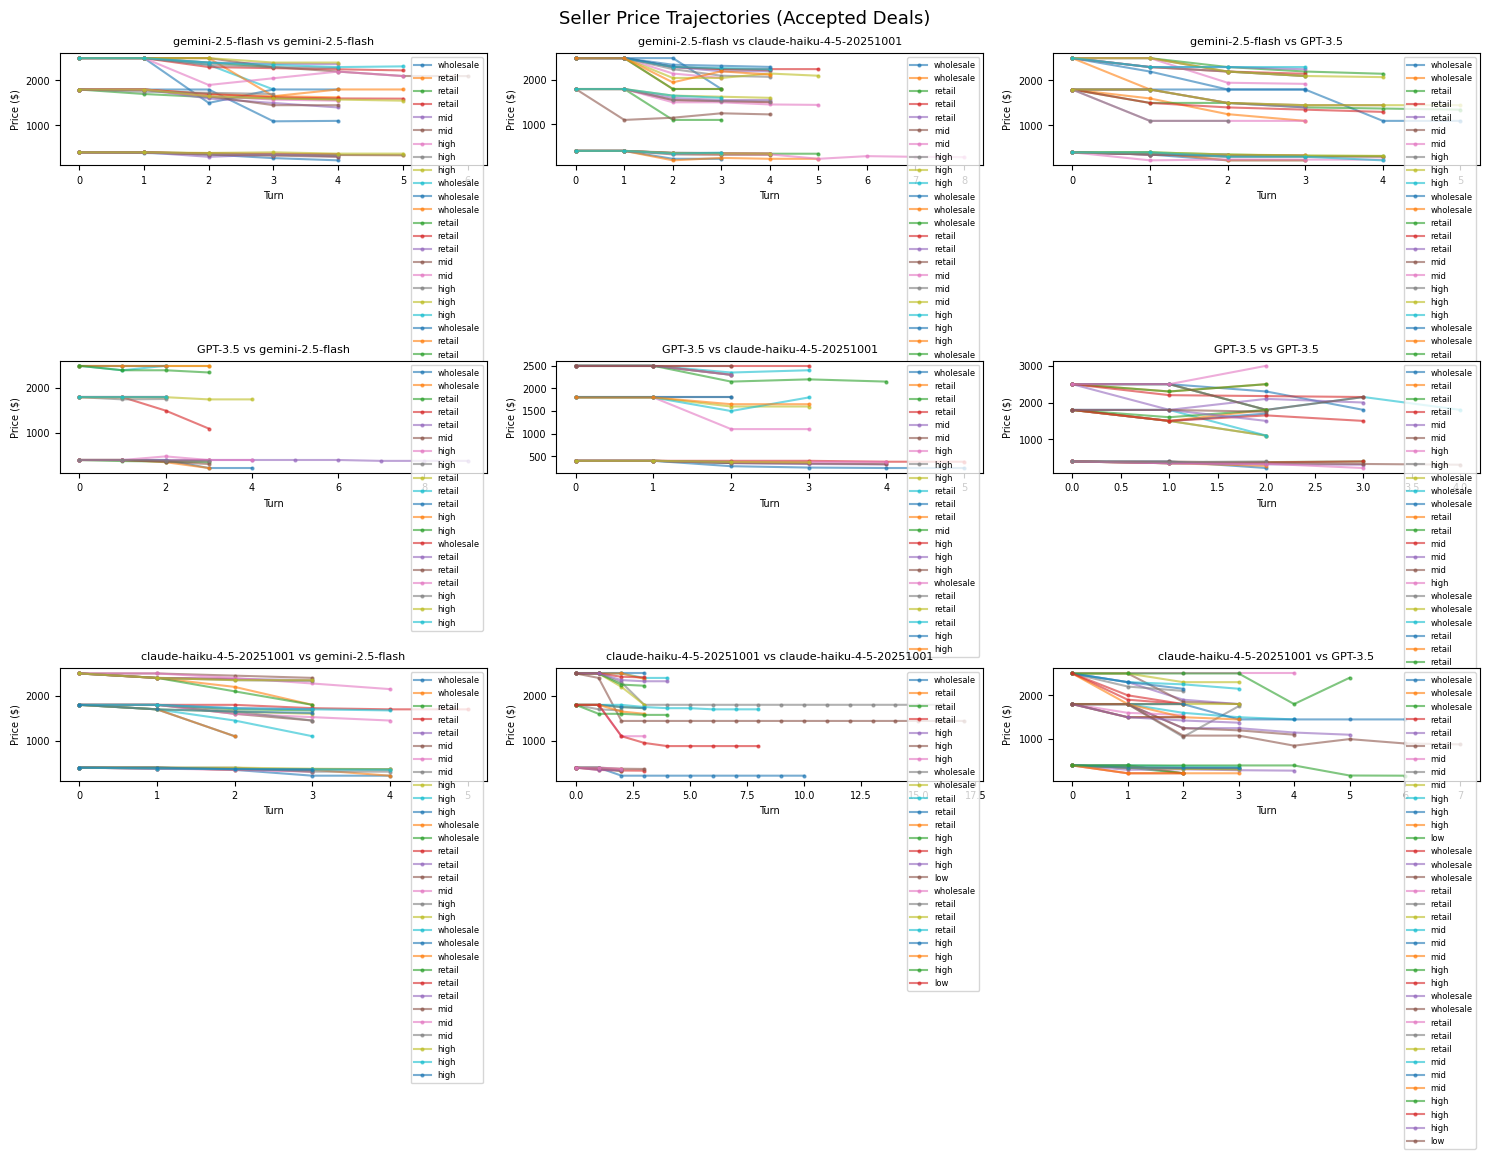

Saved to /content/A2A-Negotiations/results/price_trajectory_matrix.png


In [27]:
accepted_df = df[df["accepted"]].copy()

if len(accepted_df) == 0:
    print("No accepted deals yet — trajectory chart skipped.")
else:
    buyer_models_found  = accepted_df["buyer_label"].unique()
    seller_models_found = accepted_df["seller_label"].unique()
    n_rows = len(buyer_models_found)
    n_cols = len(seller_models_found)

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(5 * n_cols, 3.5 * n_rows),
                              squeeze=False)

    for ri, buyer in enumerate(buyer_models_found):
        for ci, seller in enumerate(seller_models_found):
            ax  = axes[ri][ci]
            sub = accepted_df[(accepted_df["buyer_label"] == buyer) &
                              (accepted_df["seller_label"] == seller)]
            if sub.empty:
                ax.set_visible(False)
                continue
            for _, row in sub.iterrows():
                with open(row["file"]) as f:
                    d = json.load(f)
                ax.plot(d["seller_price_offers"], marker="o", markersize=2,
                        alpha=0.6, label=row["budget_scenario"])
            ax.set_title(f"{buyer} vs {seller}", fontsize=8)
            ax.set_xlabel("Turn", fontsize=7)
            ax.set_ylabel("Price ($)", fontsize=7)
            ax.tick_params(labelsize=7)
            ax.legend(fontsize=6, loc="upper right")

    fig.suptitle("Seller Price Trajectories (Accepted Deals)", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/price_trajectory_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {RESULTS_DIR}/price_trajectory_matrix.png")

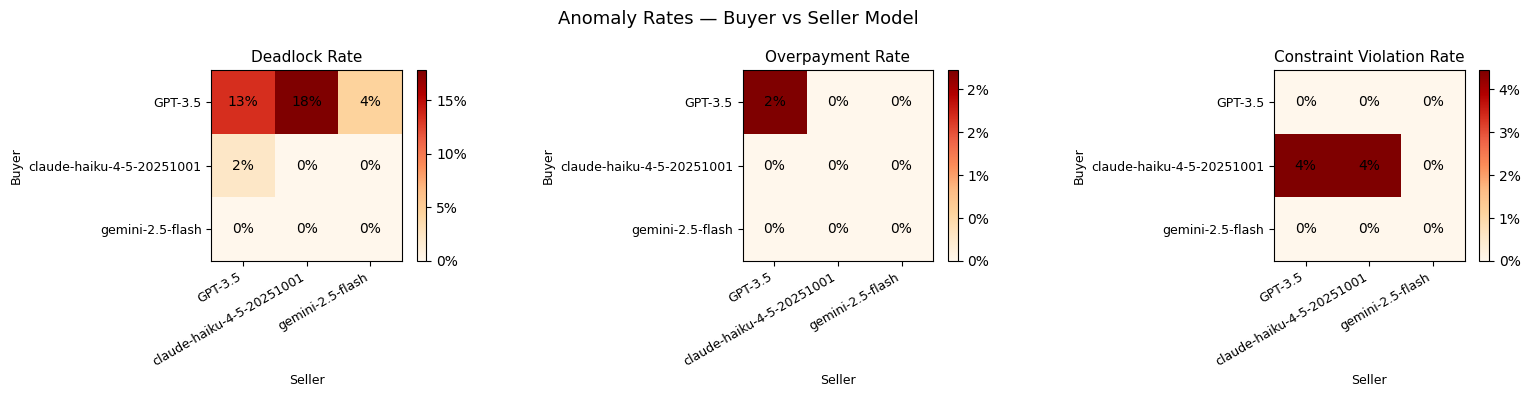

Saved to /content/A2A-Negotiations/results/anomaly_heatmaps.png


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

anomaly_specs = [
    ("deadlock",    "Deadlock Rate",         "OrRd"),
    ("overpayment", "Overpayment Rate",       "OrRd"),
    ("constraint",  "Constraint Violation Rate", "OrRd"),
]

for ax, (metric, title, cmap) in zip(axes, anomaly_specs):
    pivot = agg.pivot(index="buyer_label", columns="seller_label", values=metric)
    data  = pivot.values.astype(float)
    im    = ax.imshow(data, cmap=cmap, vmin=0, vmax=max(np.nanmax(data), 0.01))
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Seller", fontsize=9)
    ax.set_ylabel("Buyer",  fontsize=9)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = data[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.05, format="{x:.0%}")

plt.suptitle("Anomaly Rates — Buyer vs Seller Model", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/anomaly_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {RESULTS_DIR}/anomaly_heatmaps.png")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Best buyer: highest deal rate + highest PRR
buyer_rank = df.groupby("buyer_label").agg(
    deal_rate=("accepted",  "mean"),
    avg_prr  =("prr_buyer", "mean"),
).reset_index().sort_values("deal_rate", ascending=False)

x = range(len(buyer_rank))
axes[0].bar(x, buyer_rank["deal_rate"], color="steelblue", alpha=0.8, label="Deal Rate")
ax2 = axes[0].twinx()
ax2.plot(x, buyer_rank["avg_prr"], "o--", color="darkorange", label="Avg PRR %")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(buyer_rank["buyer_label"], rotation=20, ha="right")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_ylabel("Deal Rate")
ax2.set_ylabel("Avg Price Reduction %")
axes[0].set_title("Buyer Model Performance")
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# Best seller: lowest deal rate conceded (or highest avg profit)
seller_rank = df.groupby("seller_label").agg(
    deal_rate  =("accepted",       "mean"),
    avg_profit =("seller_profit",  "mean"),
).reset_index().sort_values("avg_profit", ascending=False)

x2 = range(len(seller_rank))
axes[1].bar(x2, seller_rank["avg_profit"].fillna(0), color="seagreen", alpha=0.8, label="Avg Profit ($)")
ax3 = axes[1].twinx()
ax3.plot(x2, seller_rank["deal_rate"], "s--", color="tomato", label="Deal Rate")
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(seller_rank["seller_label"], rotation=20, ha="right")
axes[1].set_ylabel("Avg Seller Profit ($)")
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax3.set_ylabel("Deal Rate")
axes[1].set_title("Seller Model Performance")
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle("Model Rankings", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model_rankings.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {RESULTS_DIR}/model_rankings.png")

---
## 6 · Save outputs

In [30]:
# Master CSV
csv_path = f"{RESULTS_DIR}/all_results.csv"
df.drop(columns=["file"]).to_csv(csv_path, index=False)
print(f"Master CSV   -> {csv_path}  ({len(df)} rows)")

# Model-pair summary CSV
summary_path = f"{RESULTS_DIR}/model_pair_summary.csv"
agg.to_csv(summary_path, index=False)
print(f"Pair summary -> {summary_path}")

# Pivot CSVs
for metric, name in [("deal_rate","deal_rate"), ("avg_prr","prr"),
                      ("deadlock","deadlock"),   ("avg_turns","avg_turns")]:
    p = agg.pivot(index="buyer_label", columns="seller_label", values=metric)
    p.to_csv(f"{RESULTS_DIR}/pivot_{name}.csv")
    print(f"Pivot {name:<12} -> {RESULTS_DIR}/pivot_{name}.csv")

print("\nAll outputs saved.")

Master CSV   -> /content/A2A-Negotiations/results/all_results.csv  (405 rows)
Pair summary -> /content/A2A-Negotiations/results/model_pair_summary.csv
Pivot deal_rate    -> /content/A2A-Negotiations/results/pivot_deal_rate.csv
Pivot prr          -> /content/A2A-Negotiations/results/pivot_prr.csv
Pivot deadlock     -> /content/A2A-Negotiations/results/pivot_deadlock.csv
Pivot avg_turns    -> /content/A2A-Negotiations/results/pivot_avg_turns.csv

All outputs saved.


---
## 7 · Browse transcripts

Change `TRANSCRIPT_BUYER` and `TRANSCRIPT_SELLER` to browse any pair.

In [31]:
import textwrap

TRANSCRIPT_BUYER  = BUYER_MODELS[0]   # change to any buyer model
TRANSCRIPT_SELLER = SELLER_MODELS[0]  # change to any seller model

sub = df[(df["buyer_model"] == TRANSCRIPT_BUYER) &
         (df["seller_model"] == TRANSCRIPT_SELLER)]

if sub.empty:
    print(f"No results for {TRANSCRIPT_BUYER} vs {TRANSCRIPT_SELLER}")
else:
    target = sub[sub["accepted"]].iloc[0] if sub["accepted"].any() else sub.iloc[0]
    with open(target["file"]) as f:
        data = json.load(f)
    print(f"Buyer        : {target['buyer_model']}")
    print(f"Seller       : {target['seller_model']}")
    print(f"Product      : {target['product_name']}")
    print(f"Budget       : ${target['budget']:.2f}  ({target['budget_scenario']})")
    print(f"Result       : {target['result']}")
    print(f"Final price  : ${target['final_price']:.2f}")
    print(f"Turns        : {target['completed_turns']}")
    print("=" * 60)
    for turn in data["conversation_history"]:
        prefix  = f"[{turn['speaker']}] "
        wrapped = textwrap.fill(turn["message"], width=90,
                                subsequent_indent=" " * len(prefix))
        print(f"{prefix}{wrapped}\n")

Buyer        : gpt-3.5-turbo
Seller       : gpt-3.5-turbo
Product      : Sony WH-1000XM5 Wireless Headphones
Budget       : $220.00  (wholesale)
Result       : accepted
Final price  : $220.00
Turns        : 1
[Buyer] Hello there! I hope you're doing well. I came across your listing for the Sony WH-1000XM5
        Wireless Headphones and I'm really interested in them. I was wondering if there is
        any room for negotiation on the price? Looking forward to hearing from you. Thank
        you!

[Seller] Hello! I'm glad to hear you're interested in the Sony WH-1000XM5 Wireless Headphones. They
         are great headphones indeed. While I understand your interest in negotiating, the
         price for these headphones is already quite competitive. Would you like to
         proceed with the purchase at the listed price?

[Buyer] Thank you for considering my interest. I have a budget of $220.00 for this purchase. Would
        you be able to offer a lower price within my budget?

[Sell

In [36]:
import os, glob

# Check what's actually in results/
files = glob.glob(f"{RESULTS_DIR}/**/*", recursive=True)
print(f"Files in results/: {len(files)}")
for f in files[:20]:
    print(" ", f)

# Check if there's a .gitignore blocking it
gi = f"{REPO_DIR}/.gitignore"
if os.path.exists(gi):
    print("\n.gitignore contents:")
    print(open(gi).read())

Files in results/: 592
  /content/A2A-Negotiations/results/pivot_deadlock.csv
  /content/A2A-Negotiations/results/model_pair_summary.csv
  /content/A2A-Negotiations/results/all_results.csv
  /content/A2A-Negotiations/results/pivot_deal_rate.csv
  /content/A2A-Negotiations/results/pivot_prr.csv
  /content/A2A-Negotiations/results/model_rankings.png
  /content/A2A-Negotiations/results/price_trajectory_matrix.png
  /content/A2A-Negotiations/results/heatmap_deal_rate.png
  /content/A2A-Negotiations/results/deal_rate_by_budget_matrix.png
  /content/A2A-Negotiations/results/heatmap_prr.png
  /content/A2A-Negotiations/results/analysis.ipynb
  /content/A2A-Negotiations/results/pivot_avg_turns.csv
  /content/A2A-Negotiations/results/seller_gemini-2.5-flash
  /content/A2A-Negotiations/results/anomaly_heatmaps.png
  /content/A2A-Negotiations/results/seller_claude-haiku-4-5-20251001
  /content/A2A-Negotiations/results/seller_gpt-3.5-turbo
  /content/A2A-Negotiations/results/seller_gemini-2.5-flash

In [39]:
import subprocess, os, shutil

GITHUB_TOKEN = ""
GITHUB_USER  = "catchshashank"
REPO_NAME    = "A2A-Negotiations"

repo_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git"
os.chdir(REPO_DIR)
subprocess.run(["git", "remote", "set-url", "origin", repo_url], check=True)
subprocess.run(["git", "config", "user.email", "you@example.com"], check=True)
subprocess.run(["git", "config", "user.name", GITHUB_USER], check=True)

# Stage results, patched source files, Config.py, and notebook
subprocess.run(["git", "add", "-f", "results/"],      check=True)  # -f forces past .gitignore
subprocess.run(["git", "add", "Config.py"],           check=True)
subprocess.run(["git", "add", "core/Conversation.py"], check=True)
subprocess.run(["git", "add", "core/LanguageModel.py"], check=True)
subprocess.run(["git", "add", "main.py"],              check=True)

# Copy and stage notebook
nb_src = "/content/a2a_nego_matrix.ipynb"
if os.path.exists(nb_src):
    shutil.copy(nb_src, f"{REPO_DIR}/a2a_nego_matrix.ipynb")
    subprocess.run(["git", "add", "a2a_nego_matrix.ipynb"], check=True)

# Verify what's staged
status = subprocess.run(["git", "status"], capture_output=True, text=True)
print(status.stdout)

# Commit if anything staged
result = subprocess.run(
    ["git", "commit", "-m", "Add results, patched source files, and notebook"],
    capture_output=True, text=True
)
print(result.stdout or result.stderr)

# Push
subprocess.run(["git", "push", "origin", "main"], check=True)
print("Done.")

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   Config.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	__pycache__/
	core/__pycache__/


[main 817ac50] Add results, patched source files, and notebook
 1 file changed, 5 insertions(+)
 create mode 100644 Config.py



CalledProcessError: Command '['git', 'push', 'origin', 'main']' returned non-zero exit status 1.